# Medical Insurance Claim Prediction

In [104]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
   
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from xgboost import XGBRegressor
import joblib  


In [105]:
import warnings
warnings.filterwarnings("ignore") 

In [106]:
df=pd.read_csv("insurance.csv")
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [108]:
df.shape

(1340, 10)

In [109]:
pd.set_option('display.float_format',"{:.2f}".format)

In [110]:
sns.set(style="whitegrid",palette="Set2",font_scale=1.1)

In [111]:
df.duplicated().sum()

0

In [112]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [113]:
df.dropna(inplace=True)

In [114]:
df.shape

(1332, 10)

In [115]:
df.describe(include="all")

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.00,1332.00,1332,1332.00,1332.00,1332,1332.00,1332,1332,1332.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.47,38.09,NaN,30.66,94.19,NaN,1.10,NaN,NaN,13325.25
std,384.70,11.11,NaN,6.12,11.45,NaN,1.21,NaN,NaN,12109.62
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,341.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,4760.16
50%,674.50,38.00,NaN,30.35,92.00,NaN,1.00,NaN,NaN,9412.97
75%,1007.25,47.00,NaN,34.73,99.00,NaN,2.00,NaN,NaN,16781.33


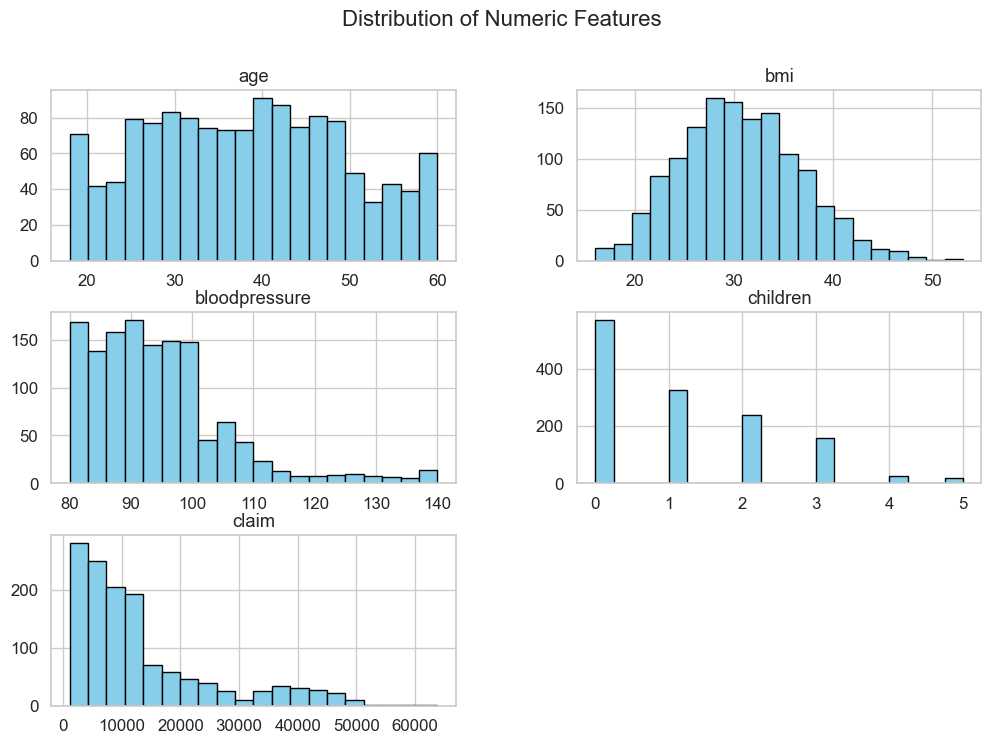

In [116]:
numeric_cols=["age","bmi","bloodpressure","children","claim"]
df[numeric_cols].hist(bins=20,figsize=(12,8),color="skyblue",edgecolor="black")
plt.suptitle("Distribution of Numeric Features",fontsize=16)
plt.show()

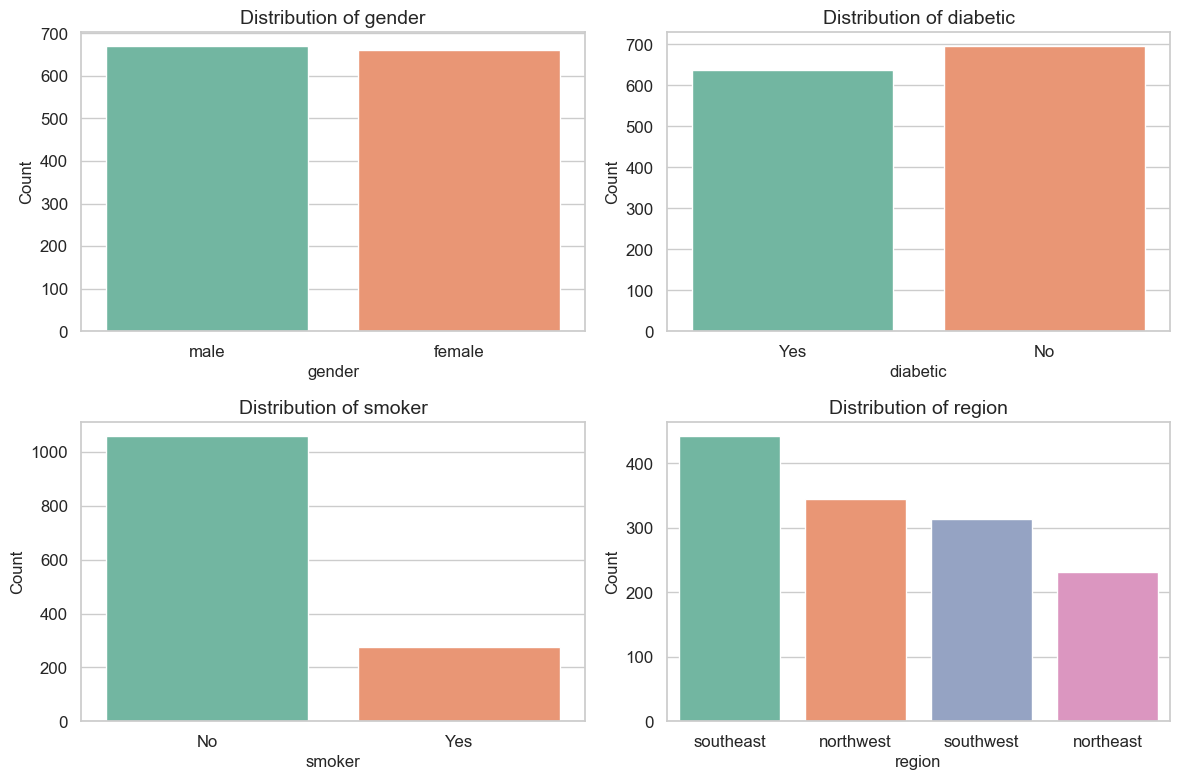

In [117]:
cat_cols=["gender","diabetic","smoker","region"]
plt.figure(figsize=(12,8))

for i,col in enumerate(cat_cols,1):
    plt.subplot(2,2,i)
    sns.countplot(data=df,x=col,palette="Set2")
    plt.title(f"Distribution of {col}",fontsize=14)
    plt.xlabel(col,fontsize=12)
    plt.ylabel("Count",fontsize=12)
plt.tight_layout()
plt.show()

In [118]:
df.groupby(["gender","smoker"])["claim"].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

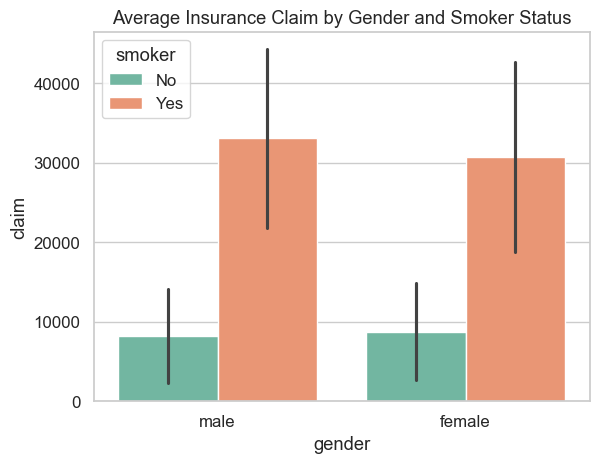

In [119]:
plt
sns.barplot(data=df,x="gender",y="claim",hue="smoker",estimator="mean",palette="Set2",errorbar="sd")
plt.title("Average Insurance Claim by Gender and Smoker Status")
plt.show()

In [120]:
pivot_region_diabetic=df.groupby(["region","diabetic"])["claim"].mean().unstack()

In [121]:
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


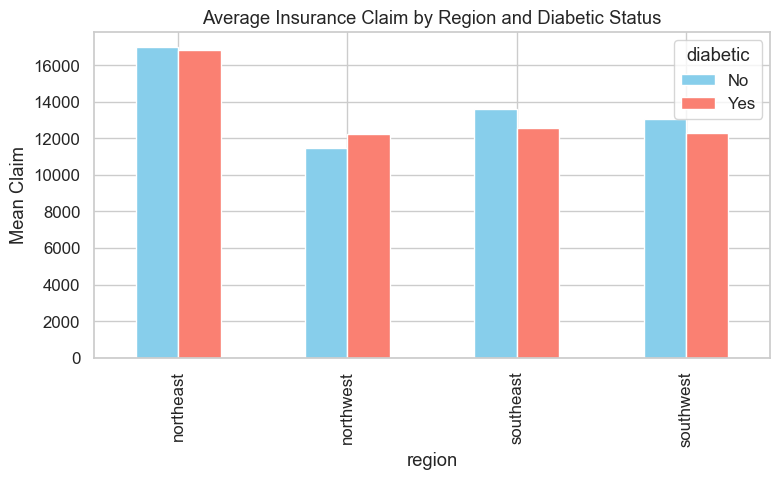

In [122]:
pivot_region_diabetic.plot(kind="bar",figsize=(8,5),color=["skyblue","salmon"])
plt.title("Average Insurance Claim by Region and Diabetic Status")
plt.ylabel("Mean Claim")
plt.tight_layout()
plt.show()

In [123]:
pivot_table=pd.pivot_table(df,values="claim",index="region",columns="smoker",aggfunc="mean")
pivot_table

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [124]:
pivot_table=pd.pivot_table(df,values="claim",index="children",columns="diabetic",aggfunc="mean")
pivot_table

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


In [125]:
df[numeric_cols].corr()

,age,bmi,bloodpressure,children,claim
age,1.00,-0.04,-0.06,-0.03,-0.03
bmi,-0.04,1.00,0.14,0.01,0.20
bloodpressure,-0.06,0.14,1.00,-0.03,0.53
children,-0.03,0.01,-0.03,1.00,0.06
claim,-0.03,0.20,0.53,0.06,1.00


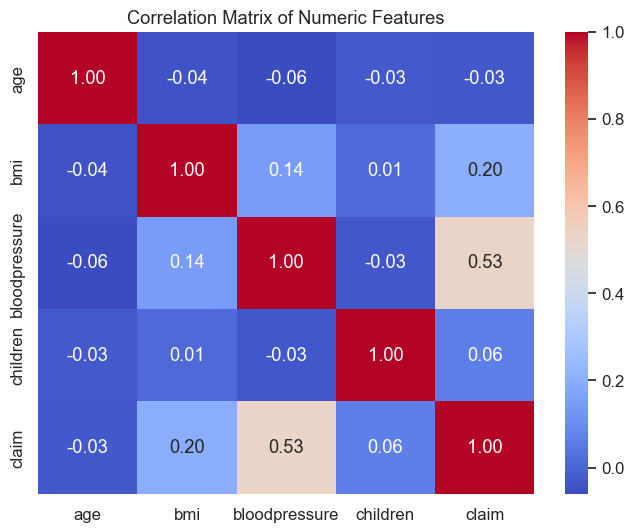

In [126]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")     
plt.show()


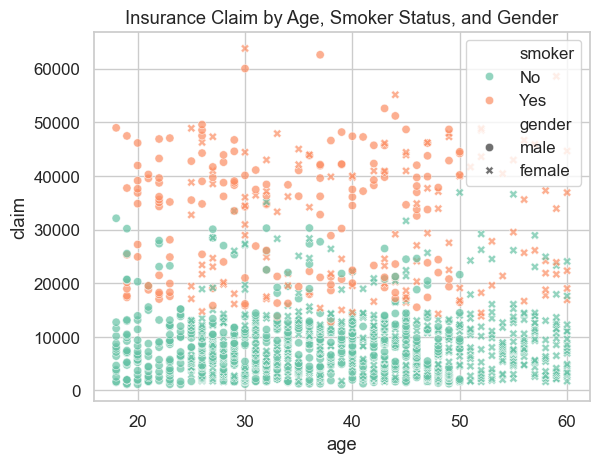

In [127]:
sns.scatterplot(data=df,x="age",y="claim",hue="smoker",style="gender",alpha=0.7,palette="Set2")
plt.title("Insurance Claim by Age, Smoker Status, and Gender")
plt.show()

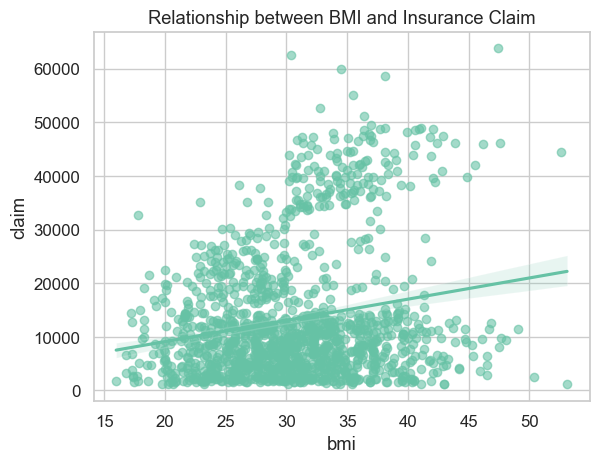

In [128]:
sns.regplot(data=df,x="bmi",y="claim",scatter_kws={"alpha":0.6})
plt.title("Relationship between BMI and Insurance Claim")
plt.show()

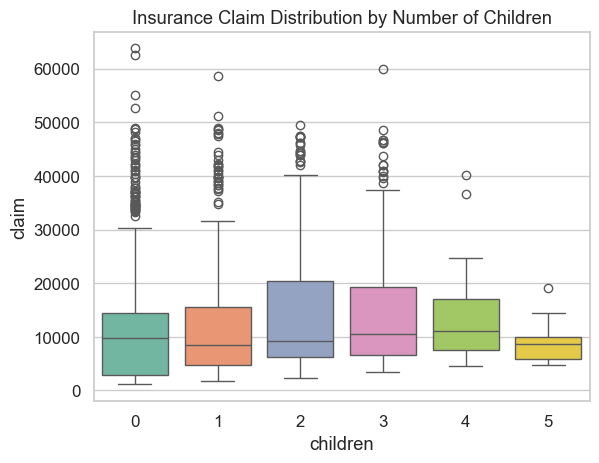

In [129]:
sns.boxplot(data=df,x="children",y="claim",palette="Set2")
plt.title("Insurance Claim Distribution by Number of Children")
plt.show()

In [130]:
df["age_group"]=pd.cut(df["age"],bins=[0,18,30,45,60,100],labels=["<18","18-30","31-45","46-60","60+"])

In [131]:
df["age_group"].value_counts()

age_group
31-45    553
46-60    383
18-30    380
<18       16
60+        0
Name: count, dtype: int64

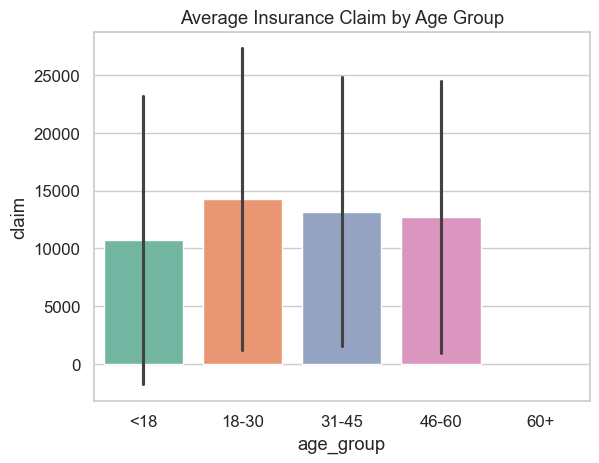

In [132]:
sns.barplot(data=df,x="age_group",y="claim",estimator="mean",palette="Set2",errorbar="sd")
plt.title("Average Insurance Claim by Age Group")
plt.show()

In [133]:
df["bmi_category"]=pd.cut(df["bmi"],bins=[0,18.5,24.9,29.9,100],labels=["Underweight","Normal","Overweight","Obese"])

In [134]:
df["bmi_category"].value_counts()

bmi_category
Obese          702
Overweight     387
Normal         222
Underweight     21
Name: count, dtype: int64

Text(0.5, 1.0, 'Insurance Claim Distribution by BMI Category')

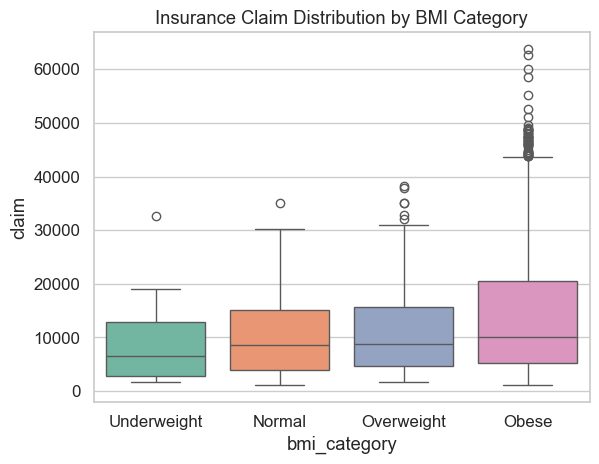

In [135]:
sns.boxplot(data=df,x="bmi_category",y="claim",palette="Set2")
plt.title("Insurance Claim Distribution by BMI Category")

## *Feature Engineering*

In [136]:
region_stats=df.groupby("region").agg(
    smoker_rate=("smoker",lambda x: (x=="Yes").mean()*100),
    mean_claim=("claim","mean")
).reset_index()

In [137]:
region_stats

,region,smoker_rate,mean_claim
0,northeast,29.00,16889.04
1,northwest,16.81,11794.22
2,southeast,20.59,13085.50
3,southwest,18.47,12723.13


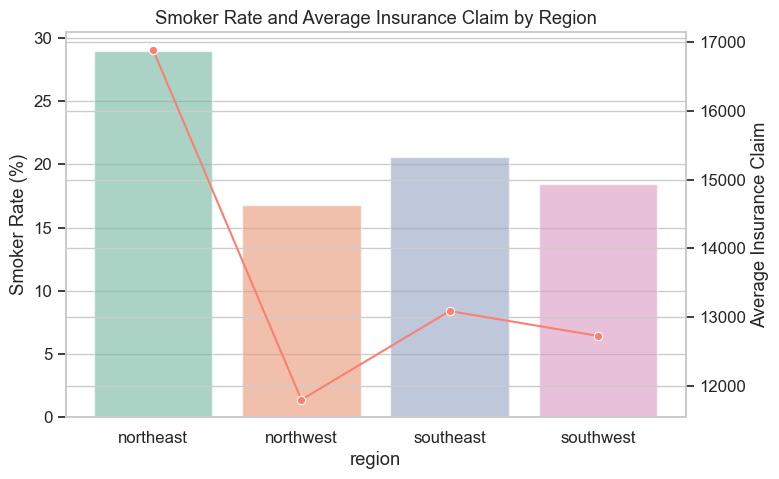

In [138]:
fig,ax1=plt.subplots(figsize=(8,5))
sns.barplot(data=region_stats,x="region",y="smoker_rate",ax=ax1,alpha=0.6,palette="Set2")
ax2=ax1.twinx()
sns.lineplot(data=region_stats,x="region",y="mean_claim",ax=ax2,color="salmon",marker="o")
ax1.set_ylabel("Smoker Rate (%)")
ax2.set_ylabel("Average Insurance Claim")
plt.title("Smoker Rate and Average Insurance Claim by Region")
plt.show()

In [139]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [140]:
# Features & Target
X = df[["age","gender","bmi","bloodpressure","diabetic","children","smoker","region"]]
y = np.log1p(df["claim"])   # log transform for better performance


In [141]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [142]:
# Column Separation
numeric_features = ["age","bmi","bloodpressure","children"]
categorical_features = ["gender","diabetic","smoker","region"]


In [143]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

## *Baseline Model*

In [144]:
baseline = DummyRegressor(strategy="mean")

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", baseline)
    ]
)

baseline_pipeline.fit(X_train, y_train)

baseline_pred_log = baseline_pipeline.predict(X_test)

baseline_pred = np.expm1(baseline_pred_log)
y_test_actual = np.expm1(y_test)

baseline_r2 = r2_score(y_test_actual, baseline_pred)
baseline_mae = mean_absolute_error(y_test_actual, baseline_pred)

print("Baseline R2:", round(baseline_r2,3))
print("Baseline MAE:", round(baseline_mae,3))


Baseline R2: -0.127
Baseline MAE: 8194.027


# *Random Forest Tuning*

In [145]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ]
)

rf_params = {
    "model__n_estimators": [100,200],
    "model__max_depth": [None,10,20],
    "model__min_samples_split": [2,5],
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

rf_pred_log = best_rf.predict(X_test)
rf_pred = np.expm1(rf_pred_log)

rf_r2 = r2_score(y_test_actual, rf_pred)
rf_mae      = mean_absolute_error(y_test_actual, rf_pred)
rf_rmse     = np.sqrt(mean_squared_error(y_test_actual, rf_pred))

print("Random Forest R2:", round(rf_r2,3))
print("Random Forest MAE:", round(rf_mae,3))
print("Random Forest RMSE:", round(rf_rmse,3))
print("Best RF Params:", rf_grid.best_params_)

Random Forest R2: 0.804
Random Forest MAE: 3820.441
Random Forest RMSE: 5316.346
Best RF Params: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}


# *XGBoost Tuning*

In [146]:
# Pipeline
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(objective="reg:squarederror", random_state=42))
    ]
)

# Hyperparameter Grid
param_grid = {
    "model__n_estimators": [100,200],
    "model__max_depth": [3,6],
    "model__learning_rate": [0.01,0.1],
    "model__subsample": [0.8,1.0]
}

In [147]:
# Grid Search
grid_search = GridSearchCV(
    model_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

In [148]:
# Predictions (log space)
y_pred_log = best_model.predict(X_test)

# Convert back to original scale
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

# Metrics
r2 = r2_score(y_test_actual, y_pred)
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

print("Test R2:", round(r2,3))
print("Test MAE:", round(mae,2))
print("Test RMSE:", round(rmse,2))

Test R2: 0.808
Test MAE: 3797.62
Test RMSE: 5263.06


## *Cross-Validation Reliability Check*

In [149]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    grid_search.best_estimator_,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("CV R2 Scores:", cv_scores)
print("Mean CV R2:", round(np.mean(cv_scores),3))

CV R2 Scores: [0.56380624 0.55485491 0.61021697 0.58156889 0.59141758]
Mean CV R2: 0.58


In [150]:
print("XGBoost R2:", round(r2,3))
print("Random Forest R2:", round(rf_r2,3))

XGBoost R2: 0.808
Random Forest R2: 0.804


In [151]:
results = pd.DataFrame({
    "Model": ["Baseline", "Random Forest", "XGBoost"],
    "R2": [baseline_r2, rf_r2, r2]
})

results.sort_values(by="R2", ascending=False)

,Model,R2
2,XGBoost,0.81
1,Random Forest,0.80
0,Baseline,-0.13


# *Feature Importance*

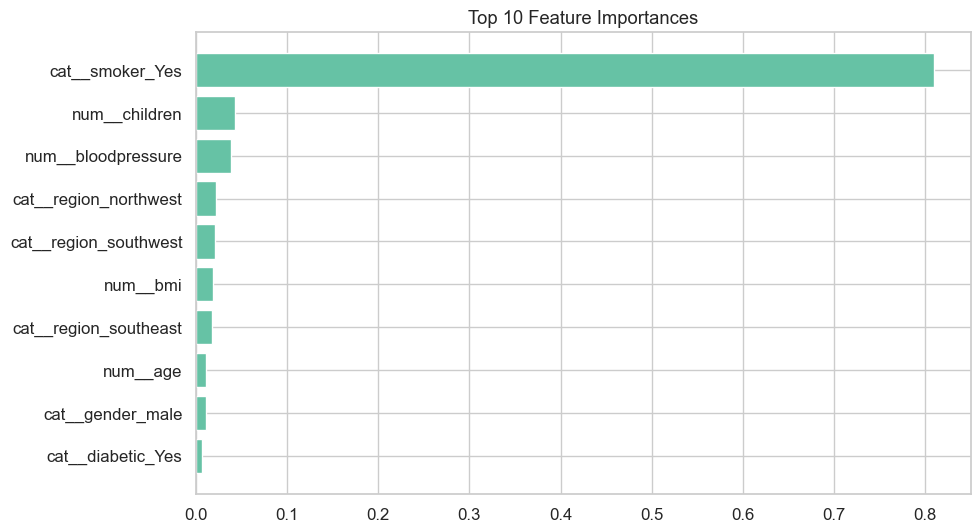

In [152]:
import matplotlib.pyplot as plt
import pandas as pd

model = best_model.named_steps["model"]
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importances = model.feature_importances_

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_df["Feature"][:10], feat_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.show()

# *Residual Analysis*

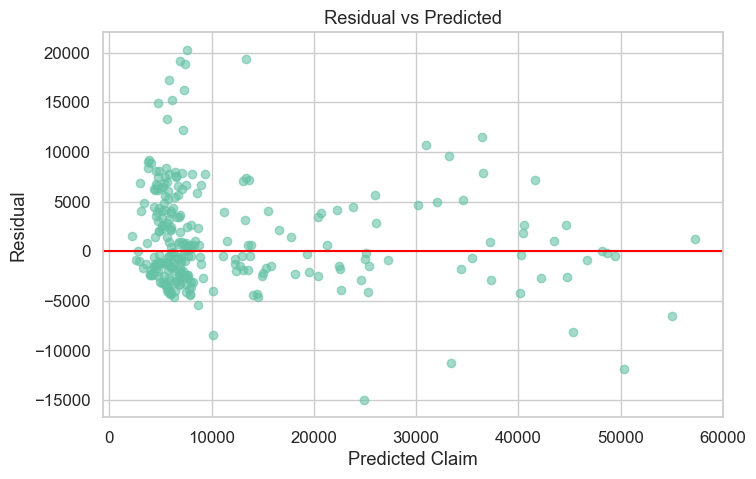

In [153]:
residuals = y_test_actual - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color="red")
plt.xlabel("Predicted Claim")
plt.ylabel("Residual")
plt.title("Residual vs Predicted")
plt.show()

# *Final Model Selection & Export*

In [154]:
if r2 > rf_r2:
    final_model = best_model
    print("Final Model: XGBoost")
else:
    final_model = best_rf
    print("Final Model: Random Forest")

joblib.dump(final_model, "insurance_claim_pipeline.pkl")

Final Model: XGBoost


['insurance_claim_pipeline.pkl']